# PINN Model Using Literature Data
This model uses **experimental data from Zhou et al. (2025)**. 

# Imports

In [843]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from scipy.stats import lognorm, weibull_min, genextreme, kstest
import torch
import torch.nn as nn

# 1. Input Parameters
collects all inputs from experimental data and literature

## 1.1. Literature Data

In [844]:
cleaned_sheets = pd.read_excel("/Users/jessiekreinsen/pinn-project/data/data_zhou_cleaned.xlsx", sheet_name=None)

with open("/Users/jessiekreinsen/pinn-project/data/data_zhou_metadata.json", "r") as f:
    metadata = json.load(f)

datasets = {}

for sheet_name, df in cleaned_sheets.items():
    datasets[sheet_name] = metadata[sheet_name]
    datasets[sheet_name]["data"] = df

*Data from* Zhou, S., Henrich, M., Wei, Z., Feng, F., Yang, B., & Münstermann, S. (2025). A general physics-informed neural network framework for fatigue life prediction of metallic materials. Engineering Fracture Mechanics, 322, 111136.

In [845]:
# see available datasets
for name, info in datasets.items():
    print(name)
    print("  material:", info["material"])
    print("  category:", info["category"])
    print("  columns:", info["columns"])

Case 1 LZ50 steel
  material: LZ50 steel
  category: fatigue_life
  columns: ['stress_max', 'fatigue_life_cycles', 'log_life', 'temperature_k']
Case 2 SLM 316l
  material: SLM 316L
  category: fracture_mechanics
  columns: ['stress_max', 'deltaK', 'sqrt_A', 'l_leff', 'Nf']
Case 3 7075_T6_ratio
  material: Al7075-T6
  category: fatigue_life
  columns: ['stress_max', 'r-ratio', 'Nf']
Case 4 Al2024_T4
  material: Al2024
  category: stress_concentration
  columns: ['stress_max', 'r-ratio', 'Kt', 'Nf']
Case 4 Al7175_T7511
  material: Al7175
  category: stress_concentration
  columns: ['stress_max', 'r-ratio', 'Kt', 'Nf']
Case 4 Ti-4.5Al-3V-2Fe-2Mo
  material: Ti-4.5Al-3V-2Fe-2Mo
  category: stress_concentration
  columns: ['stress_max', 'r-ratio', 'Kt', 'Nf']
Case4 ZK60A-T5
  material: ZK60A-T5
  category: stress_concentration
  columns: ['stress_max', 'r-ratio', 'Kt', 'Nf']
Case 5 AMS 5707
  material: AMS 5707
  category: fatigue_life
  columns: ['stress_amp', 'Nf', 'r-ratio', 'temperature

### 1.1.a. Data Cleaning

In [846]:
df_raw = datasets["Case 2 SLM 316l"]["data"].copy()

print("Raw Columns:", df_raw.columns.tolist())
print(df_raw.head())

Raw Columns: ['stress_max', 'deltaK', 'sqrt_A', 'l_leff', 'Nf']
   stress_max  deltaK  sqrt_A  l_leff      Nf
0         400    4.05      95    1.01  256343
1         400    4.54     117    1.00  197813
2         360    3.34      80    1.00  386505
3         360    4.29     132    1.00  325494
4         330    1.95      32    1.03  685035


In [847]:
# confirm no missing values
print("\nMissing values:")
print(df_raw.isnull().sum())

print(f"\nShape: {df_raw.shape}")
print(df_raw.describe())


Missing values:
stress_max    0
deltaK        0
sqrt_A        0
l_leff        0
Nf            0
dtype: int64

Shape: (44, 5)
       stress_max     deltaK      sqrt_A     l_leff            Nf
count   44.000000  44.000000   44.000000  44.000000  4.400000e+01
mean   296.022727   3.359773  113.977273   1.029773  8.012786e+05
std     53.554792   0.751809   41.102531   0.059669  8.116100e+05
min    180.000000   1.840000   32.000000   0.920000  1.234240e+05
25%    270.000000   2.955000   86.500000   1.000000  3.119738e+05
50%    270.000000   3.335000  114.000000   1.015000  5.107765e+05
75%    330.000000   3.822500  132.000000   1.050000  8.686485e+05
max    400.000000   5.930000  282.000000   1.230000  3.296187e+06


In [848]:
df = df_raw.copy()

print(df.columns.to_list())
print(df.head())

['stress_max', 'deltaK', 'sqrt_A', 'l_leff', 'Nf']
   stress_max  deltaK  sqrt_A  l_leff      Nf
0         400    4.05      95    1.01  256343
1         400    4.54     117    1.00  197813
2         360    3.34      80    1.00  386505
3         360    4.29     132    1.00  325494
4         330    1.95      32    1.03  685035


In [849]:
# convert columns to numeric
df["stress_max"] = pd.to_numeric(df["stress_max"], errors="coerce")
df["deltaK"] = pd.to_numeric(df["deltaK"], errors="coerce")
df["sqrt_A"] = pd.to_numeric(df["sqrt_A"], errors="coerce")
df["l_leff"] = pd.to_numeric(df["l_leff"], errors="coerce")
df["Nf"] = pd.to_numeric(df["Nf"], errors="coerce")

### 1.1.b. Data Extraction

In [850]:
# pull columns into numpy arrays for modeling
stress_max = df["stress_max"].to_numpy()
dKi = df["deltaK"].to_numpy()
sqrt_A = df["sqrt_A"].to_numpy()
l_leff = df["l_leff"].to_numpy()
Nf = df["Nf"].to_numpy()

# add column with converted √area, [micrometers] to area/crack size [m]
df["a0"] = (sqrt_A * 1e-6)**2           

# pull column into numpy arrays for modeling
a0 = df["a0"].to_numpy()

In [851]:
Nf_samples = df["Nf"].to_numpy(dtype=float)
sqrt_A_um = df["sqrt_A"].to_numpy(dtype=float)
dKi_samples = df["deltaK"].to_numpy(dtype=float)

sqrt_A_m = sqrt_A_um * 1e-6
a0 = sqrt_A_m**2

# clean valid positive values
sqrt_A_um = sqrt_A_um[np.isfinite(sqrt_A_um)]
sqrt_A_um = sqrt_A_um[sqrt_A_um > 0]

# convert to meters if desired
sqrt_A_m = sqrt_A_um * 1e-6

In [852]:
# define a function to filter datasets by required columns
def get_datasets_with(required_cols):
    selected = {}

    for name, info in datasets.items():
        df = info["data"]

        if all(col in df.columns for col in required_cols):
            selected[name] = info

    return selected

defect_sets = get_datasets_with(["stress_max", "defect_size_m", "Nf"])

for name, info in defect_sets.items():
    print(name, info["material"])

Case 8 Al-Mg4.5-Mn Al-Mg4.5-Mn
Case Ti-6.5Al-2Zr-Mo-V Ti-6.5Al-2Zr-Mo-V


## 1.2. Material Parameters
Paris law constants, fracture toughness, threshold SIF

Paris–Erdogan law:  **da/dN = C · ΔK^m**
- valid for  K_th < ΔK < K_c  (Stage II crack growth)

In [853]:
# for SLM 316l
C_SLM = 7.0e-15
m_SLM = 6.0

# for Ti6Al4V from LPBF
C_Ti = 0.76899e-7     # Paris constant [m/cycle / (MPa√m)^m]
m_Ti = 2.56492        # Paris exponent

print(f"Paris law: da/dN = {C_SLM:.2e} * deltaK^{m_SLM}")

Paris law: da/dN = 7.00e-15 * deltaK^6.0


*For Paris constants, C and m, for SLM:*
Kluczynski, J. et al. (2020). Crack Growth Behavior of Additively Manufactured 316L Steel—Influence of Build Orientation and Heat Treatment. *Materials*. MDPI. DOI:10.3390/ma13153259

*For Paris constants, C and m, for Ti6Al4V from LPBF:*
Wang, H. et al. (2022). Fatigue performance at ultra-low porosity of Ti6Al4V produced by laser powder bed fusion after post heat treatment. *SSRN Electronic Journal*. <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4224194>.

## 1.3. Geometry Parameters
specimen dimensions, defect location (→ Y factor)

In [854]:
# specimen dimensions: assume cylinderical gauge section, A = π * (d/2)^2
h = 50e-3               # height [m]
d = 10e-3               # diameter [m]
A = np.pi * (d/2)**2    # cross-sectional area [m^2]

V_gauge = A * h                # gauge volume [m^3]
V_gauge_mm3 = V_gauge * 1e9    # [mm^3] for display

print(f"Gauge volume V = {V_gauge_mm3:.1f} mm^3")

Gauge volume V = 3927.0 mm^3


Specimen dimensions given by Zhou et al. (2025); assumed cylindrical.

**Note:** Specimen dimensions are not necessary in this model.

In [855]:
# add column with geometry correction factor Y (Murakami framework)
#   Y = 0.5 for internal defect
#   Y = 0.65 for surface defect
defect_location = "internal"
df["Y"] = 0.5 if defect_location == "internal" else 0.65

if defect_location == "internal":
    print(f"Defect location: {defect_location} → Y = 0.5")
else:
    print(f"Defect location: {defect_location} → Y = 0.65")

# pull column into numpy arrays for modeling
Y = df["Y"].to_numpy()

Defect location: internal → Y = 0.5


All defects are assumed **critical** and **internal** since the defect location is not given in the dataset from Zhou et al. (2025), nor is it given in any of the cited sources in the paper, and since internal defects have a greater effect than surface defects (Bonneric, M. et al. (2025)).

Bonneric, M. et al. (2025). Influence of the defect size, type, and position on the high cycle fatigue behavior of Ti-6Al-4V processed by laser powder bed fusion. International Journal of Fatigue, 193, 108783.

## 1.4. Loading Parameters
stress amplitude, mean stress, frequency

frequency, R given in Zhou et al. (2025)

In [856]:
stress_max = df["stress_max"]             # max stress [MPa]
freq = 30       # cyclic frequency [Hz]
R = 0.1
# R = stress_min / stress_max if stress_max != 0 else float("nan")

stress_min = R * stress_max
stress_a = (stress_max - stress_min) / 2    # stress amplitude [MPa]

# Effective stress range:
    # crack faces close under compression, no damage contribution
delta_sigma = stress_max - stress_min

# 2. Defect Size Distribution
Through fracture mechanics and the Paris law, the critical defect size controls the fatigue life.

This section will present a parametric PDF fit to measured defect sizes

## 2.2. Defect Size Distribution
Since Zhou reports √A, this data is treated as the **critical defect**.

The distribution of the defects is fitted and plotted.

### 2.2.a. Distribution Parameters
Since the Zhou dataset directly reports the critical defect size √A, the distribution parameters are estimated **directly from the experimental √A values** rather than from a VED-based synthetic model.

In [857]:
# distribution parameters fitted directly from experimental √area data
sqrt_A_um_valid = sqrt_A_um[np.isfinite(sqrt_A_um) & (sqrt_A_um > 0)]

# lognormal parameters from measured √area [μm]
sigma_ln, loc_ln, scale_ln = lognorm.fit(sqrt_A_um_valid, floc=0)

mu_ln = np.log(scale_ln)
median_sqrt_A = np.exp(mu_ln)

print("Experimental defect-size distribution parameters:")
print(f"  mu_ln = {mu_ln:.4f}")
print(f"  sigma_ln = {sigma_ln:.4f}")
print(f"  median √A = {median_sqrt_A:.2f} μm")

Experimental defect-size distribution parameters:
  mu_ln = 4.6753
  sigma_ln = 0.3560
  median √A = 107.26 μm


### 2.2.b. Fit Parametric PDF
Three candidate distributions are fitted by MLE.

The best distribution is selected by the lowest Kolmogorov–Smirnov statistic.

In [858]:
# define a function to fit a parametric distribution to the defect sizes by MLE
def fit_distribution(sizes, dist_name):
    # lognormal distribution
    if dist_name == "lognormal":
        s, loc, scale = lognorm.fit(sizes, floc=0)
        frozen = lognorm(s=s, loc=0, scale=scale)
        params = {"mu_ln": np.log(scale), "sigma_ln": s}

    # Weibull distribution (3-parameter, with loc fixed at 0)
    elif dist_name == "Weibull":
        k, loc, scale = weibull_min.fit(sizes, floc=0)
        frozen = weibull_min(c=k, loc=0, scale=scale)
        params = {"k": k, "lambda": scale}

    # Gumbel distribution (for maxima, with loc and scale)
    elif dist_name == "Gumbel":
        from scipy.stats import gumbel_r
        loc, scale = gumbel_r.fit(sizes)
        frozen = gumbel_r(loc=loc, scale=scale)
        params = {"loc": loc, "scale": scale}

    else:
        raise ValueError(f"Unknown distribution: {dist_name!r}")

    ks_stat, ks_p = kstest(sizes, frozen.cdf)
    return frozen, ks_stat, ks_p, params

# fit each candidate distribution
data = sqrt_A_um

candidates = ["lognormal", "Weibull", "Gumbel"]
fit_results = {}

In [859]:
# print results in a table to compare goodness-of-fit
print(f"{'Distribution':<12}  {'KS statistic':>14}  {'p-value':>10}")
print("-" * 42)

for name in candidates:
    frozen, ks, p, params = fit_distribution(data, name)
    fit_results[name] = (frozen, ks, p, params)
    print(f"{name:<12}  {ks:>14.4f}  {p:>10.4f}")

best_name = min(fit_results, key=lambda n: fit_results[n][1])
best_frozen, best_ks, best_p, best_params = fit_results[best_name]
print(f"\nBest fit: {best_name} (KS = {best_ks:.4f}, p = {best_p:.4f})")

param_str = ", ".join(f"{k} = {v:.4g}" for k, v in best_params.items())
print(f"Parameters: {param_str}")

Distribution    KS statistic     p-value
------------------------------------------
lognormal             0.0938      0.7999
Weibull               0.1279      0.4322
Gumbel                0.0908      0.8296

Best fit: Gumbel (KS = 0.0908, p = 0.8296)
Parameters: loc = 95.94, scale = 33.23


### 2.2.c. Defect Size Histogram & PDF

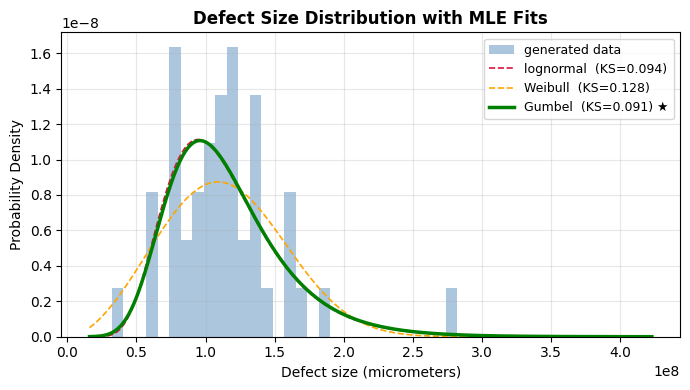

In [860]:
# plot histogram of defect sizes and overlay fitted PDFs
fig, ax = plt.subplots(figsize=(7, 4))

sizes_um = data * 1e6   # convert to micrometers for readability
ax.hist(sizes_um, bins=30, density=True, alpha=0.45,
        color="steelblue", label="generated data")

# overlay all three fitted PDFs
colors = {"lognormal": "crimson", "Weibull": "orange", "Gumbel": "green"}
x_m = np.linspace(data.min() * 0.5, data.max() * 1.5, 500)
x_um = x_m * 1e6

for name, (frozen, ks, p, _) in fit_results.items():
    pdf_vals = frozen.pdf(x_m) / 1e6   # Jacobian: dx_m = dx_um / 1e6
    lw = 2.5 if name == best_name else 1.2
    ls = "-" if name == best_name else "--"
    ax.plot(x_um, pdf_vals, color=colors[name], linewidth=lw, linestyle=ls,
            label=f"{name}  (KS={ks:.3f})" + (" ★" if name == best_name else ""))

# axes labels, title
ax.set_title("Defect Size Distribution with MLE Fits", fontweight="bold")
ax.set_xlabel("Defect size (micrometers)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_defect_pdf.png", dpi=150)
plt.show()

**Gumbel** is the best fit for this data; whereas, it was assumed lognormal was the best when generating synthetic data.

# 3. Fatigue-Life Statistics
Experimental fatigue lives and defect measurements from Zhou et al. (2025) are analyzed using the Paris law and the Shiozawa framework and reliability methods.

The resulting distributions captures the scatter from defect variability.

## 3.1. Paris & Shiozawa Formulas
Integrating Paris law from a_0 to a_f with the Shiozawa approximation
(a_f >> a_i, so the a_f term → 0 for m > 2):

        N_f ≈ 2 / [(m-2) · C · (Y·delta_sigma)^m · pi^(m/2)] · a_i^(1 - m/2)

Re-written in terms of the initial SIF range deltaK_i = Y·delta_sigma·√(pi·a_i):

        N_f ≈ 2 / [(m-2) · C · pi · (Y·delta_sigma)^2] · deltaK_i^(2-m)

In [861]:
# define function based on Paris law
def fatigue_life_paris(a_i, stress_a, C, m, Y, delta_sigma=None):

    # fully reversed (R = -1)
    if delta_sigma is None:
        delta_sigma = 2.0 * stress_a
    
    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * np.pi**(m/2))

    Nf = paris_coeff * a_i**(1.0-(m/2.0))
    return Nf

def fatigue_life_paris_torch(a0, stress_a, C, m, Y, delta_sigma=None):

    # fully reversed loading, R = -1
    if delta_sigma is None:
        delta_sigma = 2.0 * stress_a

    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * torch.pi**(m / 2.0))

    Nf = paris_coeff * a0**(1.0 - (m / 2.0))
    return Nf

The **stress intensity factor, delta(K)**, the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [862]:
# define function to compute stress intensity factor, deltaK
def stress_intensity_factor(stress_amp, defect_size):
    deltaK = Y * stress_amp * np.sqrt(np.pi * defect_size)
    return deltaK

def stress_intensity_factor_torch(stress_amp, defect_size):
    deltaK = Y * stress_amp * torch.sqrt(torch.pi * defect_size)
    return deltaK

# define a function to compute the initial SIF range deltaK_i for a given initial crack size a_i
def delta_K_initial(a_i, delta_sigma, Y):
    deltaK_i = Y * delta_sigma * np.sqrt(np.pi * a_i)   # [MPa√m]
    return deltaK_i

## 3.2. Experimental Fatigue-Life Statistics


In [863]:
#S_fixed = 500.0   # stress amplitude [MPa]

Nnorm_samples = Nf_samples / sqrt_A_m

# create one shared mask for valid rows (positive finite fatigue lives)
valid_mc = (
    np.isfinite(a0) &
    np.isfinite(Nf_samples) & (Nf_samples > 0) &
    np.isfinite(dKi_samples) & (dKi_samples > 0) &
    np.isfinite(Nnorm_samples) & (Nnorm_samples > 0)
)

# apply the same mask to everything
a0_valid = a0[valid_mc]
Nf_samples_valid = Nf_samples[valid_mc]
dKi_samples_valid = dKi_samples[valid_mc]
Nnorm_samples_valid = Nnorm_samples[valid_mc]

### 3.2.a. Shiozawa Plot: deltaK_i vs N_f / √A
Expected slope from Paris law:
(N/√A) ∝ (deltaK_i)^(-m)
log(deltaK_i) = -(1/m)*log(N/√A) + C
→ **slope = -1/m**

In [864]:
# log-log linear fit
log_Nnorm = np.log10(Nnorm_samples_valid).flatten()
log_dKi = np.log10(dKi_samples_valid).flatten()

In [865]:
# fit line
slope, intercept = np.polyfit(log_Nnorm, log_dKi, 1)
a_fit = 10**intercept

# compare slope to expected from Paris law
expected_slope = -1.0 / m_SLM

# convert to numpy arrays
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

N_norm_line = np.logspace(
    np.log10(Nnorm_samples.min()),
    np.log10(Nnorm_samples.max()),
    300
)
dK_line = a_fit * N_norm_line**slope

In [866]:
# convert data to tensors for plotting and PINN
a_tensor = torch.tensor(a0_valid, dtype=torch.float32).unsqueeze(1)           # input = max defect / initial crack size
Nf_tensor = torch.tensor(Nf_samples_valid, dtype=torch.float32).unsqueeze(1)  # output = fatigue life
stress_min_valid = torch.tensor(stress_min, dtype=torch.float32).unsqueeze(1)

Y_valid = torch.tensor(df["Y"].to_numpy(dtype=float)[valid_mc],
                       dtype=torch.float32).unsqueeze(1)
    #Y[valid_mc], dtype=torch.float32).unsqueeze(1)
stress_max_valid = torch.tensor(df["stress_max"].to_numpy(dtype=float)[valid_mc],
                                dtype=torch.float32).unsqueeze(1)

delta_sigma_valid = stress_max_valid - stress_min_valid
stress_a_valid = delta_sigma_valid / 2

Shiozawa log-log fit: slope = -0.1885
Expected from Paris (m=6.0): slope = -0.1667


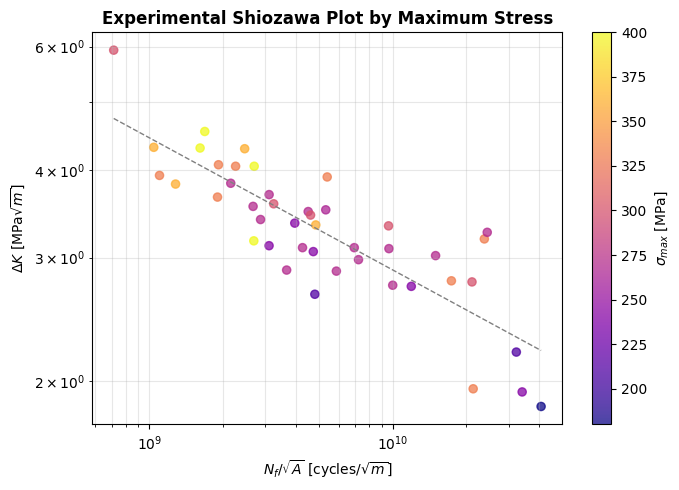

In [867]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(Nnorm_samples_valid, dKi_samples_valid,
    c=stress_max_valid.detach().numpy().squeeze(),
    cmap="plasma", alpha=0.75, s=35)

# show fitted line from log-log fit
ax.plot(N_norm_line, dK_line, color="grey", linewidth=1, linestyle="--",
        label=f"Fit: $\\Delta K_i$ = {a_fit:.2e}*(N/√A)^{slope:.3f}")

# log scale
ax.set_xscale("log")
ax.set_yscale("log")

# label, titles
ax.set_xlabel(r"$N_f/\sqrt{A}$ [cycles/$\sqrt{m}$]")
ax.set_ylabel(r"$\Delta K$ [MPa$\sqrt{m}$]")
ax.set_title(r"Experimental Shiozawa Plot by Maximum Stress",
             fontweight="bold")

# legend, colobar, grid
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\sigma_{max}$ [MPa]")
ax.grid(alpha=0.3, which="both")

print(f"Shiozawa log-log fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m_SLM}): slope = {expected_slope:.4f}")

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_shiozawa_experimental_stress.png", dpi=150)
plt.show()

### 3.2.b. Reliability Curves

The fraction of specimens surviving beyond N cycles:

**R(N) = P(N_f > N)**

The Weibull model **R(N) = exp[-(N/η)^β]** is fitted for comparison

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

Weibull: β = 1.139, η = 8.453e+05
  B10 (10% failure) = 1.172e+05 cycles
  B50 (50% failure) = 6.128e+05 cycles


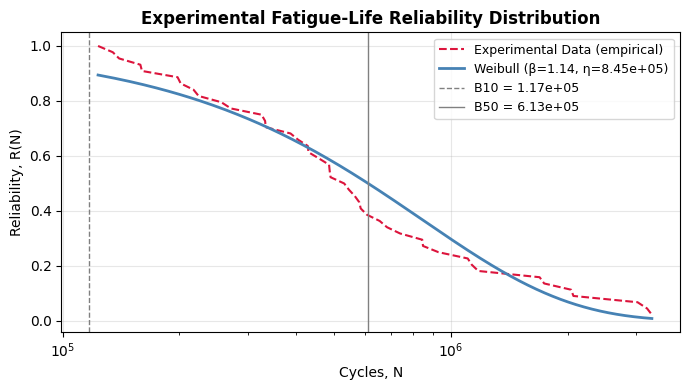

In [868]:
lives_sorted = np.sort(Nf_samples_valid)
R_empirical  = 1.0 - np.arange(len(lives_sorted)) / len(lives_sorted)

# Weibull MLE fit
shape_w, _, scale_w = weibull_min.fit(Nf_samples_valid, floc=0)
N_vals = np.linspace(lives_sorted.min(), lives_sorted.max(), 500)
R_weibull = np.exp(-(N_vals / scale_w)**shape_w)

# B10 and B50 lives
B10 = scale_w * (-np.log(0.90))**(1.0 / shape_w)        # 10% failure → R = 0.90
B50 = scale_w * (-np.log(0.50))**(1.0 / shape_w)        # 50% failure → R = 0.50
print(f"Weibull: β = {shape_w:.3f}, η = {scale_w:.3e}")
print(f"  B10 (10% failure) = {B10:.3e} cycles")
print(f"  B50 (50% failure) = {B50:.3e} cycles")

# plot reliability curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lives_sorted, R_empirical, color="crimson", linewidth=1.5,
        linestyle="--", label="Experimental Data (empirical)")
ax.plot(N_vals, R_weibull, color="steelblue", linewidth=2,
        label=f"Weibull (β={shape_w:.2f}, η={scale_w:.2e})")

# show B10 and B50 as vertical lines
ax.axvline(B10, color="grey", linewidth=1, linestyle="--",
           label=f"B10 = {B10:.2e}")
ax.axvline(B50, color="grey", linewidth=1,
           label=f"B50 = {B50:.2e}")

# log scale for reliability plot
ax.set_xscale("log")

# axes labels, title
ax.set_title(f"Experimental Fatigue-Life Reliability Distribution",
             fontweight="bold")
ax.set_xlabel("Cycles, N")
ax.set_ylabel("Reliability, R(N)")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_reliability.png", dpi=150)
plt.show()

### 3.2.c. S-N Curves
experimental S-N curves

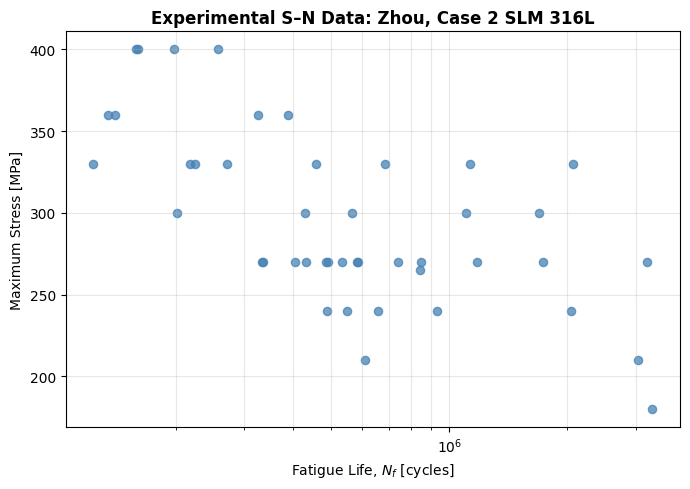

In [869]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Nf_samples_valid,
           stress_max_valid.detach().numpy().squeeze(),
           color="steelblue", alpha=0.75, s=35,
           label="Experimental Data")

# log scale
ax.set_xscale("log")

# labels, title
ax.set_xlabel(r"Fatigue Life, $N_f$ [cycles]")
ax.set_ylabel(r"Maximum Stress [MPa]")
ax.set_title("Experimental S–N Data: Zhou, Case 2 SLM 316L",
             fontweight="bold")

# grid, legend
ax.grid(alpha=0.3, which="both")
#ax.legend()

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_experimental_SN.png", dpi=150)
plt.show()

#### 3.2.c.i. PSN Curves
Binned percentiles are used to create a sort of probabilistic S-N curve.

In [870]:
stress_exp = stress_max_valid.detach().numpy().squeeze()
life_exp = Nf_samples_valid

# create stress bins to store fatigue life data
stress_bins = np.array([200, 250, 300, 350, 400, 450])

bin_centers = []
B10 = []
B50 = []
B90 = []

for i in range(len(stress_bins) - 1):
    mask = (stress_exp >= stress_bins[i]) & (stress_exp < stress_bins[i+1])
    lives_bin = life_exp[mask]

    if len(lives_bin) < 3:
        continue

    bin_centers.append(0.5 * (stress_bins[i] + stress_bins[i+1]))
    B10.append(np.quantile(lives_bin, 0.10))
    B50.append(np.quantile(lives_bin, 0.50))
    B90.append(np.quantile(lives_bin, 0.90))

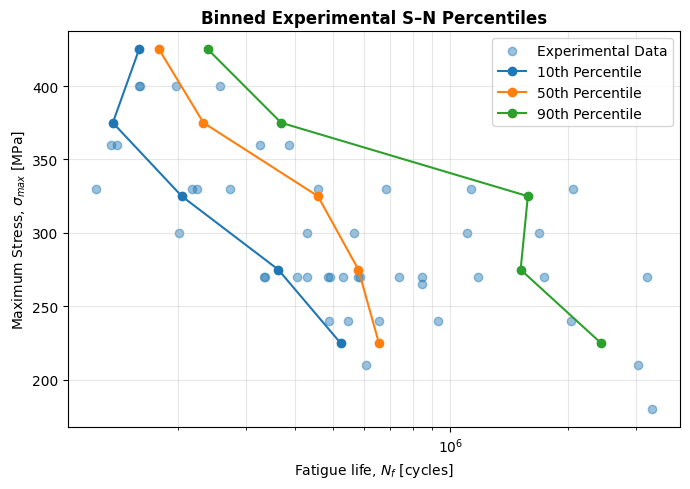

In [871]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(life_exp, stress_exp, alpha=0.45, label="Experimental Data")

# add probabilities of failure
ax.plot(B10, bin_centers, marker="o", label="10th Percentile")
ax.plot(B50, bin_centers, marker="o", label="50th Percentile")
ax.plot(B90, bin_centers, marker="o", label="90th Percentile")

# log scale
ax.set_xscale("log")

# labels, title
ax.set_xlabel(r"Fatigue life, $N_f$ [cycles]")
ax.set_ylabel(r"Maximum Stress, $\sigma_{max}$ [MPa]")
ax.set_title("Binned Experimental S–N Percentiles",
             fontweight="bold")

# legend, grid
ax.grid(alpha=0.3, which="both")
ax.legend()

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_experimental_SN_percentiles.png", dpi=150)
plt.show()

# 4. PINN

In [872]:
# reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 4.1. Train/Test Split
Data is split into 70% training, 30% test as in Zhou et al. (2025).

In [873]:
# reproducible random split
n = a_tensor.shape[0]
rng = torch.Generator().manual_seed(42)
perm = torch.randperm(n, generator=rng)

n_train = int(0.70 * n)
train_idx = perm[:n_train]
test_idx  = perm[n_train:]

# split physical tensors
a_train = a_tensor[train_idx]
a_test  = a_tensor[test_idx]

Nf_train = Nf_tensor[train_idx]
Nf_test  = Nf_tensor[test_idx]

Y_train = Y_valid[train_idx]
Y_test  = Y_valid[test_idx]

stress_a_train = stress_a_valid[train_idx]
stress_a_test  = stress_a_valid[test_idx]

delta_sigma_train = delta_sigma_valid[train_idx]
delta_sigma_test  = delta_sigma_valid[test_idx]

print(f"Total samples: {n}")
print(f"Train samples: {len(train_idx)}")
print(f"Test samples:  {len(test_idx)}")

Total samples: 44
Train samples: 30
Test samples:  14


In [874]:
# log-transform
log_a_train = torch.log(a_train)
log_a_test = torch.log(a_test)

log_Nf_train = torch.log(Nf_train)
log_Nf_test = torch.log(Nf_test)

# compute normalization from TRAIN ONLY
log_a_mean = log_a_train.mean()
log_a_std = log_a_train.std()

log_Nf_mean = log_Nf_train.mean()
log_Nf_std = log_Nf_train.std()

# scale train and test
a_train_scaled = (log_a_train - log_a_mean) / log_a_std
a_test_scaled = (log_a_test - log_a_mean) / log_a_std

N_train_scaled = (log_Nf_train - log_Nf_mean) / log_Nf_std
N_test_scaled = (log_Nf_test - log_Nf_mean) / log_Nf_std

## 4.2. Define PINN

In [875]:
# # define data
# X = [a0, stress_max, Y]
# y = Nf

In [876]:
# define custom NN class
# lets PyTorch track parameters and gradients automatically
class PINN(nn.Module):
    def __init__(self): # initializes nn.Module
        super().__init__()
        self.net = nn.Sequential( # sequential container for layers, = feed-forward pipeline
            
            # first hidden layer
            nn.Linear(1, 64), # (input, output)
            # nn.Linear(3, 64), # if (input=3 variables)
            nn.Tanh(),
            
            # second hidden layer
            nn.Linear(64, 64),
            nn.Tanh(),

            # output = 1 number (N), since we want to predict a single fatigue life value for each input N/√A
            nn.Linear(64, 1) 
        )

    # forward method defines how input data flows through the network
    def forward(self, N):
        log_Nf_scaled = self.net(N) # predicts scaled log(Nf)

        # convert back to physical fatigue life
        log_Nf = log_Nf_scaled * log_Nf_std + log_Nf_mean
        Nf = torch.exp(log_Nf)        # makes prediction physical and positive
        
        # predicts Nf(N)
        return Nf 

PINN Architecture from Liao et al. (2025):
- 2 hidden layers 
- 64 neurons each 
- Tanh activation function

Liao et al. (2025). A physics-informed neural network method for identifying parameters and predicting remaining life of fatigue crack growth International. Journal of Fatigue, 191, 108678. https://doi.org/10.1016/j.ijfatigue.2024.108678.

## 4.3. Define Losses
In general, **Total Loss = Data Loss + Physics Loss** where the losses are given by the **mean squared errors (MSE)**.

### 4.3.a. Physics Loss: Paris Law

In [877]:
# define a function to enforce the Paris Law
# everything in physics_loss must be torch operations to allow autograd to compute gradients
def physics_loss(model, a_scaled, a_physical, stress_a, C_SLM, m, Y, delta_sigma):
    Nf_pred = model(a_scaled)
    Nf_physics = fatigue_life_paris_torch(a_physical, stress_a, C_SLM, m_SLM, Y, delta_sigma)
    return torch.mean((Nf_pred - Nf_physics)**2)    # MSE loss

### 4.3.b. Data Loss

In [878]:
# define a function to compute the data loss

# log-MSE between predicted and true defect sizes
def data_loss_logMSE(model, a_scaled, Nf_true):
    Nf_pred = model(a_scaled)
    return torch.mean((torch.log(Nf_pred) - torch.log(Nf_true))**2)

# MSE between predicted and true defect sizes
def data_loss_MSE(model, a_scaled, Nf_true):
    Nf_pred = model(a_scaled)
    return torch.mean((Nf_pred - Nf_true)**2)

Liao et al. (2025) uses 𝐿𝑜𝑠𝑠_𝐷 = 𝑀𝑆𝐸(𝑛_𝑝𝑟𝑒𝑑, 𝑛_𝑜𝑏𝑠) as the data loss function.

## 4.4. Training

In [879]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5000

loss_history = []
physics_loss_history = []
data_loss_history = []

# weights
w_d_liao = 100.0    # weight for data loss, from Liao et al. (2025)
w_p_liao = 1.0      # weight for physics loss, from Liao et al. (2025)
w_d = 0.9           # weight for data loss
w_p = 0.1           # weight for physics loss

# train for many iterations (epochs)
for epoch in range(epochs):
    optimizer.zero_grad()       # reset gradients before backprop

    # define losses
    loss_d = data_loss_MSE(model, a_train_scaled, Nf_train)               # enforces fit to data
    loss_p = physics_loss(model, a_train_scaled, a_train,
                          stress_a_train, C_SLM, m_SLM, Y_train, delta_sigma_train)    # enforces diff eqn everywhere

    # weighted total loss
    loss = w_d_liao * loss_d + w_p_liao * loss_p

    loss.backward()             # backpropagation: computes gradients of all parameters
    optimizer.step()            # updates network weights

    loss_history.append(loss.item())
    physics_loss_history.append(loss_p.item())
    data_loss_history.append(loss_d.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss.item():.4e} | "
            f"Data: {loss_d.item():.4e} | "
            f"Physics: {loss_p.item():.4e} | "
        )

Epoch     0 | Total: 2.7004e+33 | Data: 8.6258e+11 | Physics: 2.7004e+33 | 
Epoch   500 | Total: 2.7004e+33 | Data: 9.2127e+11 | Physics: 2.7004e+33 | 
Epoch  1000 | Total: 2.7004e+33 | Data: 9.0866e+11 | Physics: 2.7004e+33 | 
Epoch  1500 | Total: 2.7004e+33 | Data: 8.9711e+11 | Physics: 2.7004e+33 | 
Epoch  2000 | Total: 2.7004e+33 | Data: 8.8664e+11 | Physics: 2.7004e+33 | 
Epoch  2500 | Total: 2.7004e+33 | Data: 8.7967e+11 | Physics: 2.7004e+33 | 
Epoch  3000 | Total: 2.7004e+33 | Data: 8.7139e+11 | Physics: 2.7004e+33 | 
Epoch  3500 | Total: 2.7004e+33 | Data: 8.6388e+11 | Physics: 2.7004e+33 | 
Epoch  4000 | Total: 2.7004e+33 | Data: 8.6091e+11 | Physics: 2.7004e+33 | 
Epoch  4500 | Total: 2.7004e+33 | Data: 8.5795e+11 | Physics: 2.7004e+33 | 


*For weights (lambda_d = 100, lambda_p = 1), of first implementation*: Liao et al. (2025).

## 4.5. Predictions

In [880]:
model.eval()

with torch.no_grad():
    Nf_pred_train = model(a_train_scaled).numpy()
    Nf_pred_test = model(a_test_scaled).numpy()

a_np = a_tensor.numpy()
Nf_train_np = Nf_train.numpy()
Nf_test_np  = Nf_test.numpy()

# sort for plotting
sort_idx = np.argsort(a_np)
a_sorted = a_np[sort_idx]
Nf_train_sorted = Nf_train_np[sort_idx]
Nf_test_sorted = Nf_test_np[sort_idx]

### 4.5.a. Evaluation

In [881]:
# prediction errors
errors_test = Nf_pred_test - Nf_test_np

mse_test = np.mean(errors_test**2)        # mean squared error
rmse_test = np.sqrt(mse_test)             # root mean squared error
mae_test = np.mean(np.abs(errors_test))   # mean absolute error

# log-space errors
log_errors_test = np.log(Nf_pred_test) - np.log(Nf_test_np)

log_mse_test = np.mean(log_errors_test**2)
log_rmse_test = np.sqrt(log_mse_test)
log_mae_test = np.mean(np.abs(log_errors_test))

# print results table
print(f"{'Metric':<10} {'Value':>14} {'Log Value':>14}")
print("-" * 42)

print(f"{'MSE':<10} {mse_test:>14.4e} {log_mse_test:>14.4e}")
print(f"{'RMSE':<10} {rmse_test:>14.4e} {log_rmse_test:>14.4e}")
print(f"{'MAE':<10} {mae_test:>14.4e} {log_mae_test:>14.4e}")

Metric              Value      Log Value
------------------------------------------
MSE            2.0380e+11     3.9238e-01
RMSE           4.5144e+05     6.2641e-01
MAE            3.1250e+05     4.9368e-01


### 4.5.b. Accuracy Plots

#### 4.5.b.i. Training History Plots

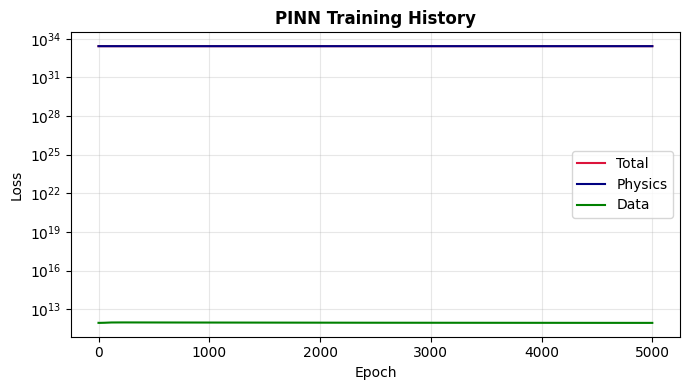

In [882]:
# plot training history
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(loss_history, color="crimson", label="Total")
ax.plot(physics_loss_history, color="navy", label="Physics")
ax.plot(data_loss_history, color="green", label="Data")

# log scale
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("PINN Training History", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/3_PINN_loss_history.png", dpi=150)
plt.show()

#### 4.4.b.ii. Predicted vs. True Defect Sizes

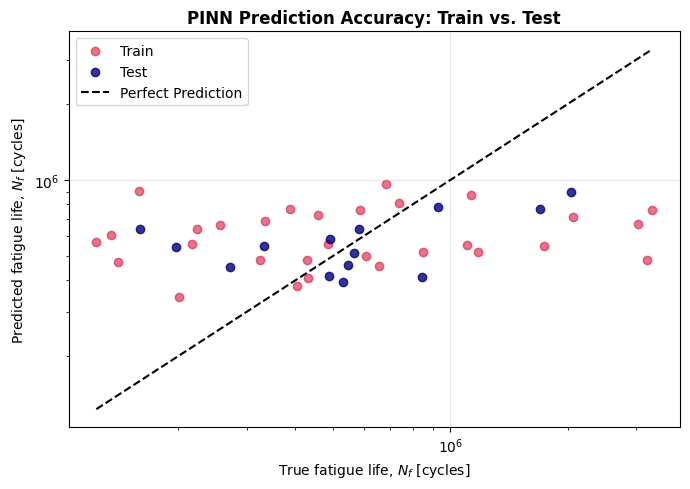

In [883]:
# plot predicted vs. true defect sizes
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Nf_train_np, Nf_pred_train,
           color="crimson",
           alpha=0.6, label="Train")
ax.scatter(Nf_test_np, Nf_pred_test,
           color="navy",
           alpha=0.8, label="Test")

min_val = min(Nf_train_np.min(), Nf_test_np.min(), Nf_pred_train.min(), Nf_pred_test.min())
max_val = max(Nf_train_np.max(), Nf_test_np.max(), Nf_pred_train.max(), Nf_pred_test.max())

ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", label="Perfect Prediction")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel(r"True fatigue life, $N_f$ [cycles]")
ax.set_ylabel(r"Predicted fatigue life, $N_f$ [cycles]")
ax.set_title("PINN Prediction Accuracy: Train vs. Test", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("graphs_pinn/3_PINN_accuracy_train_vs_test.png", dpi=150)
plt.show()

The model is fitting the train data much better than the test. There is a large amount of scatter. This is expected with so few (44) samples.

### 4.5.b. Crack Growth Curve
Plot fatigue life vs. initial defect size for train and test data

In [884]:
# convert tensors to 1D numpy arrays
a_train_np = a_train.detach().cpu().numpy().squeeze()
a_test_np  = a_test.detach().cpu().numpy().squeeze()

Nf_train_np = Nf_train.detach().cpu().numpy().squeeze()
Nf_test_np  = Nf_test.detach().cpu().numpy().squeeze()

Nf_pred_train_np = Nf_pred_train.squeeze()
Nf_pred_test_np  = Nf_pred_test.squeeze()

# sort train data by crack size
train_sort_idx = np.argsort(a_train_np)
a_train_sorted = a_train_np[train_sort_idx]
Nf_train_sorted = Nf_train_np[train_sort_idx]
Nf_pred_train_sorted = Nf_pred_train_np[train_sort_idx]

# sort test data by crack size
test_sort_idx = np.argsort(a_test_np)
a_test_sorted = a_test_np[test_sort_idx]
Nf_test_sorted = Nf_test_np[test_sort_idx]
Nf_pred_test_sorted = Nf_pred_test_np[test_sort_idx]

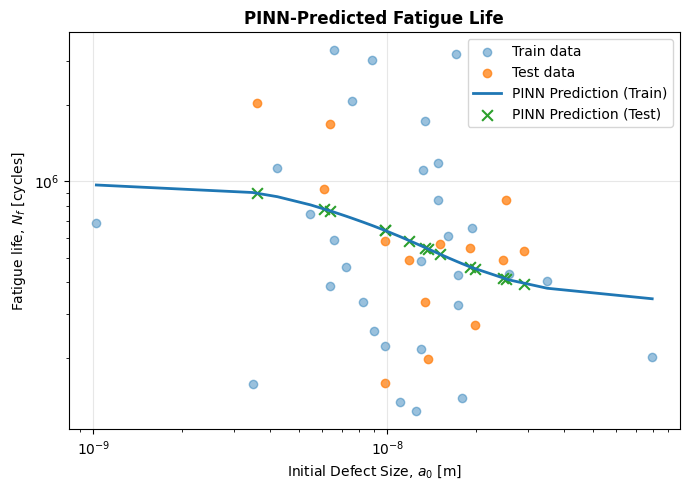

In [885]:
fig, ax = plt.subplots(figsize=(7, 5))

# true experimental data
ax.scatter(a_train_sorted, Nf_train_sorted,
           alpha=0.45, label="Train data")

ax.scatter(a_test_sorted, Nf_test_sorted,
           alpha=0.75, label="Test data")

# model predictions
ax.plot(a_train_sorted, Nf_pred_train_sorted,
        linewidth=2, label="PINN Prediction (Train)")

ax.scatter(a_test_sorted, Nf_pred_test_sorted,
           marker="x", s=60, label="PINN Prediction (Test)")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# labels, title
ax.set_xlabel(r"Initial Defect Size, $a_0$ [m]")
ax.set_ylabel(r"Fatigue life, $N_f$ [cycles]")
ax.set_title("PINN-Predicted Fatigue Life", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("graphs_pinn/3_PINN_life_vs_defect.png", dpi=150)
plt.show()

# 5. Appendix

## 5.1. Process Parameters & VED
laser power, scan speed, hatch spacing, layer thickness

The Volumetric Energy Density (VED) is the laser energy input per unit volume of material:

**VED = P / (vht)**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

and
- low VED → lack-of-fusion porosity
- high VED → keyhole porosity
- both increase defect density

In [886]:
# define dictionary of process parameters
process_params = {
    "Case 2 SLM 316l": {
        "As-printed-1": {"P": 250, "v": 850, "h": 0.12, "t": 0.05},
        "As-printed-2": {"P": 300, "v": 1126, "h": 0.14, "t": 0.05},
        "Deep cryogenic treatment": {"P": 250, "v": 850, "h": 0.12, "t": 0.05},
    }
}

Values are given in Zhou et al. (2025), but the batch/processing condition is not given in the dataset, so the parameters cannot be assigned.

In [887]:
# volumetric energy density
VED_op = P / (v * h * t)

print(f"P = {P} W,  v = {v} mm/s,  h = {h} mm,  t = {t} mm")
print(f"VED_op = {VED_op:.2f} J/mm^3")

P = 280.0 W,  v = 1200.0 mm/s,  h = 0.05 mm,  t = 0.03 mm
VED_op = 155.56 J/mm^3


*For energy densities and parameters:*
Sola, A., Nouri, A., Peyre, P., Ghodbane, J., Sanz, C., Morville, S., Hueso, J., & Aubry, P. (2021). Processability of pure copper by laser powder bed fusion and its potential applications. Additive Manufacturing, 47, 102340. <https://www.sciencedirect.com/science/article/pii/S2214860420309246#tbl0005>. 

*More data:*
van der Linde, C., Sideris, I., Deillon, L., Afrasiabi, M., & Bambach, M. (2026). Microstructure engineering of Ti-6Al-4V in laser powder bed fusion via 1D thermal modeling and supporting experiments. arXiv:2604.24669.
https://arxiv.org/html/2604.24669v1 

## 5.1.a. VED
An **empirical approximation** curve relates VED to relative density. This relationship should be treated as illustrative.

*For relative densities and optimal VED values:*
Bittner, F., Müller, B., & Thielsch, J. (2022). Efficient LPBF-process development by Design of Experiments. Fraunhofer Institute for Machine Tools and Forming Technology (IWU), Dresden, Germany. <https://publica-rest.fraunhofer.de/server/api/core/bitstreams/5db78b1a-ed75-4d57-aa78-b5712aae8a45/content>. 

*For relative density values and expected relative density vs. VED curve:*
Park, H. et al. (2024). Relationship between volumetric energy density and relative density in laser powder bed fusion additive manufacturing: A review and analysis. Journal of Powder Materials, 2024. <https://www.powdermat.org/journal/view.php?doi=10.4150/jpm.2024.00038>.

**VALUES NEED TO BE UPDATED**

In [888]:
# define VED-relative density relationship parameters
VED_opt = 81.0        # optimal VED

rd_min = 0.865        # min relative density (normalized to 1 at optimal VED)
rd_max = 0.99992      # max relative density (normalized to 1 at optimal VED)

k = 0.05              # steepness of VED curve

## 5.2. Max.-Defect Distribution
The maximum defect is given in the data by √A. Since this is the data reported by Zhou, this data was already fitted as a PDF in section 2.2. For the sake of thoroughness, it is shown.

### 5.2.a. Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

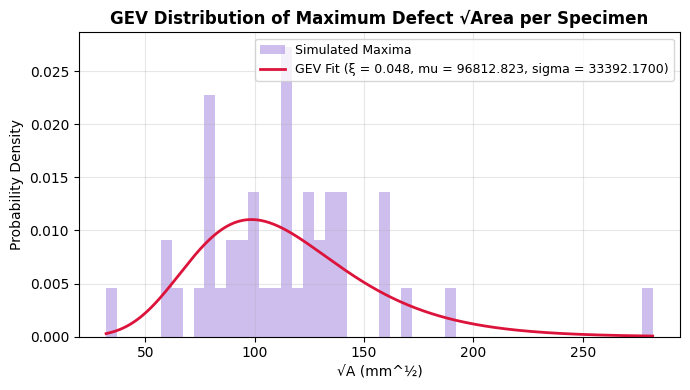

In [889]:
# GEV fit to per-specimen maximum defect sizes
        # gev_c = shape parameter (ξ)
        # gev_loc = location parameter (mu)
        # gev_scale = scale parameter (sigma)
gev_c, gev_loc, gev_scale = genextreme.fit(sqrt_A_um)

x_gev = np.linspace(sqrt_A.min(), sqrt_A.max(), 500)
pdf_gev = genextreme.pdf(x_gev, gev_c, gev_loc, gev_scale)

# convert [sqrt(m)] to [sqrt(mm)]
# conv = np.sqrt(1000)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(sqrt_A_um,
        bins=50,
        density=True,
        alpha=0.45,
        color="mediumpurple",
        label="Simulated Maxima")

ax.plot(x_gev,
        pdf_gev,
        color="crimson",
        linewidth=2,
        label=f"GEV Fit (ξ = {gev_c:.3f}, mu = {gev_loc*1e3:.3f}, sigma = {gev_scale*1e3:.4f})")

# axes labels, title
ax.set_title("GEV Distribution of Maximum Defect √Area per Specimen", fontweight="bold")
ax.set_xlabel("√A (mm^½)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_GEV.png", dpi=150)
plt.show()

## 5.3. Shiozawa Curves for Varying Stress Amps.

Each stress level produces a shifted band on the **deltaK_i vs N_f/√A** plot.

With Paris law physics, these bands should **collapse onto a single trendline** when the Murakami normalization is applied, thus confirming the consistency of the framework.

Shiozawa collapse fit: slope = -0.4232
Expected from Paris (m=2.56492): slope = -0.1667


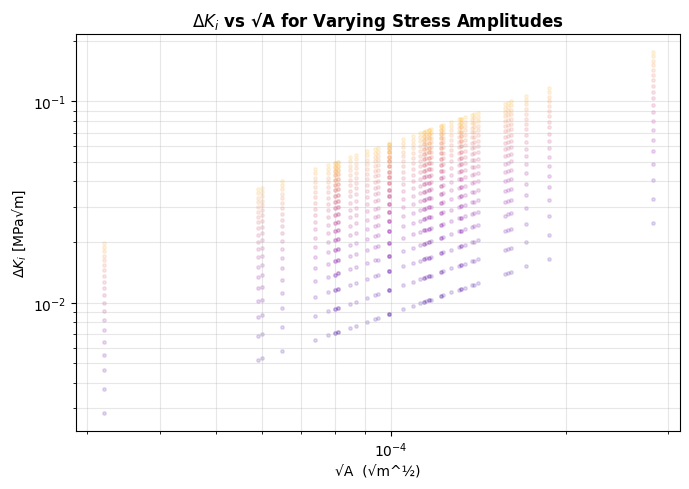

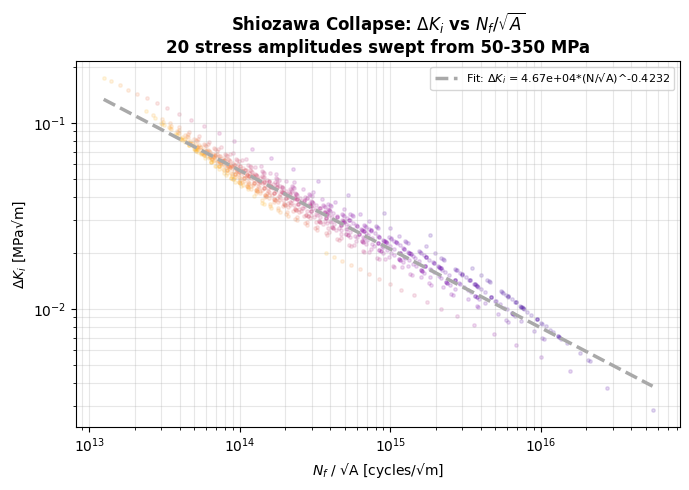

In [890]:
S_vals = np.linspace(50, 350, 20)     # stress amplitudes to sweep [MPa]

# empty lists to store info
dKi_all = []
Nnorm_all = []

# create subplots for deltaK_i vs √A and deltaK_i vs N/√A
fig1, ax1 = plt.subplots(figsize=(7, 5))    # deltaK_i vs √A
fig2, ax2 = plt.subplots(figsize=(7, 5))    # deltaK_i vs N/√A  (Shiozawa collapse)

colors_s = plt.cm.plasma(np.linspace(0.1, 0.85, len(S_vals)))

for Si, ci in zip(S_vals, colors_s):
    ds_i = 2.0 * Si                       # delta_sigma for R = -1
    
    Nf_i = fatigue_life_paris(a0, Si, C_SLM, m, Y, delta_sigma=ds_i)
    dKi_i = delta_K_initial(a0, ds_i, Y)
    sqrt_A_i = np.sqrt(a0)

    Nnorm_i = (Nf_i / sqrt_A_i)           # normalized life, N/√A [cycles/√m]
    
    # store results
    dKi_all.append(dKi_i)
    Nnorm_all.append(Nnorm_i)

    # plots
    ax1.scatter(sqrt_A_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )
    ax2.scatter(Nnorm_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )

all_dKi = np.concatenate(dKi_all) 
all_Nnorm = np.concatenate(Nnorm_all)

log_x = np.log10(all_Nnorm)
log_y = np.log10(all_dKi)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_line = np.logspace(log_x.min(), log_x.max(), 300)
y_line = 10**intercept * x_line**slope

print(f"Shiozawa collapse fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# show fitted line from log-log fit on shiozawa collapse plot
ax2.plot(x_line, y_line, color="darkgray", linewidth=2.5, linestyle="--",
         label=f"Fit: $\\Delta K_i$ = {10**intercept:.2e}*(N/√A)^{slope:.4f}")

for ax, xlabel, title in [
    # x-axis label, title for each plot
    (ax1, "√A  (√m^½)",
     "$\\Delta K_i$ vs √A for Varying Stress Amplitudes"),
    (ax2, "$N_f$ / √A [cycles/√m]",
     "Shiozawa Collapse: $\\Delta K_i$ vs $N_f/\\sqrt{A}$\n"
     "20 stress amplitudes swept from 50-350 MPa"),
]:

    # log-log scale for both plots
    ax.set_xscale("log")
    ax.set_yscale("log")

    # axes labels, titles for both plots
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\\Delta K_i$ [MPa√m]")
    ax.set_title(title, fontweight="bold")
    
    # legends, grids
    ax.grid(alpha=0.3, which="both")

ax2.legend(fontsize=8, ncol=2, #title="Stress Amplitude"
           )
# save and show
fig1.tight_layout(); fig1.savefig("graphs_pinn/2_shiozawa_dK_sqrtA.png", dpi=150)
fig2.tight_layout(); fig2.savefig("graphs_pinn/2_shiozawa_collapse.png",  dpi=150)
plt.show()

Across a dense sweep of stress amplitudes, the Shiozawa collapse is visible.